## Support Vector Classifier Implementation

In [2]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
#lets create synthetic data points

from sklearn.datasets import make_classification

In [23]:
X,y=make_classification(
    n_samples=1000,
    n_features=2,
    n_classes=2,
    n_clusters_per_class=1,
    n_redundant=0,
    random_state=3
)

In [24]:
X

array([[-0.29714013,  1.02496383],
       [ 1.42855537,  1.85565092],
       [ 1.36121443,  1.6000872 ],
       ...,
       [ 0.93892938, -0.88612263],
       [ 1.14375651, -0.87191166],
       [ 0.69833095, -0.14199537]], shape=(1000, 2))

In [25]:
pd.DataFrame(X)[0]

0     -0.297140
1      1.428555
2      1.361214
3      0.511528
4      1.669395
         ...   
995    1.132352
996    1.141032
997    0.938929
998    1.143757
999    0.698331
Name: 0, Length: 1000, dtype: float64

<Axes: xlabel='0', ylabel='1'>

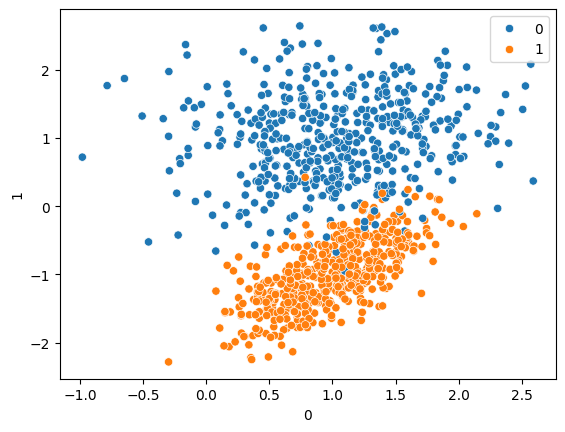

In [26]:
sns.scatterplot(x=pd.DataFrame(X)[0],y=pd.DataFrame(X)[1],hue=y)

In [29]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y, train_size=0.20 , random_state=0)

In [ ]:
from sklearn.svm import SVC
svc=SVC(kernel='linear')#when u feel data is linearly seprable

'''types of kernel u can pass 
linear 
polynomial(poly)
radial base function(rbf)
sigmoid(sigmoid)
precomputed(custom kernel)
'''

In [31]:
svc.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [32]:
#prediciton
y_pred=svc.predict(X_test)

In [33]:
from sklearn.metrics import classification_report,confusion_matrix

In [34]:
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97       397
           1       0.96      0.97      0.97       403

    accuracy                           0.97       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.97      0.97      0.97       800

[[382  15]
 [ 11 392]]


In [4]:
#for different data sets 
X1,y1=make_classification(
    n_samples=1000,
    n_features=2,
    n_classes=2,
    n_clusters_per_class=2,
    n_redundant=0,
    random_state=3
)

<Axes: xlabel='0', ylabel='1'>

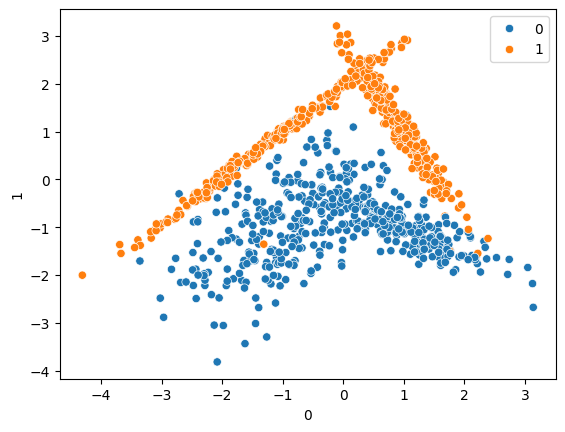

In [7]:
sns.scatterplot(x=pd.DataFrame(X1)[0],y=pd.DataFrame(X1)[1],hue=y1)

In [8]:
from sklearn.model_selection import train_test_split
X_train1,X_test1,y_train1,y_test1=train_test_split(X1,y1, train_size=0.20 , random_state=0)

In [15]:
from sklearn.svm import SVC
rbf=SVC(kernel='rbf')

In [16]:
rbf.fit(X_train1,y_train1)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [17]:
#prediciton
y_pred1=rbf.predict(X_test1)

In [18]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test1,y_pred1))
print(confusion_matrix(y_test1,y_pred1))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97       392
           1       0.95      0.99      0.97       408

    accuracy                           0.97       800
   macro avg       0.97      0.97      0.97       800
weighted avg       0.97      0.97      0.97       800

[[373  19]
 [  6 402]]


In [20]:
from sklearn.model_selection import GridSearchCV

#defining parameters
param_grid={'C':[0.1,1,10,100,1000],
            'gamma':[1,0.1,0.01,0.001,0.0001],
            'kernel':['rbf']}

In [25]:
grid=GridSearchCV(SVC(),param_grid=param_grid,refit=True,cv=5,verbose=3)

In [26]:
grid.fit(X_train1,y_train1)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.975 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.850 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.975 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.975 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.975 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.950 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.825 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.950 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=1.000 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.900 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.550 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1000


In [27]:
grid.best_params_

{'C': 1000, 'gamma': 0.01, 'kernel': 'rbf'}

In [30]:
##prediction
y_pred2=grid.predict(X_test1)
print(classification_report(y_test1,y_pred2))
print(confusion_matrix(y_test1,y_pred2))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98       392
           1       0.97      0.99      0.98       408

    accuracy                           0.98       800
   macro avg       0.98      0.98      0.98       800
weighted avg       0.98      0.98      0.98       800

[[379  13]
 [  6 402]]
